In [53]:
import pandas as pd

# Read the original CSV file
df = pd.read_csv('ndx procentai2.csv')  # replace 'your_file.csv' with your actual filename

# Calculate the monthly percentage change
df['Monthly Change (%)'] = df['Open'].pct_change() * 100

# Save the results to a new CSV file
df.to_csv('ndx procentai.csv', index=False)

print("Monthly percentage changes have been saved to 'All World basic procentai.csv'")


Monthly percentage changes have been saved to 'All World basic procentai.csv'


In [9]:
import os

print("Current working directory:", os.getcwd())


Current working directory: c:\Users\germa\AppData\Local\Programs\Microsoft VS Code


In [7]:
import pandas as pd

# Load your CSV file
df = pd.read_csv('All World basic procentai.csv')

# Ensure Date is handled properly
df['Date'] = pd.to_datetime(df['Date'], format='%m/%Y')

# Initialize new column for adjusted balance after withdrawals
df['Adjusted Value'] = df['Monthly Change (%)'].copy()

# Apply 7% withdrawal every July starting from 2000
for i in range(1, len(df)):
    current_date = df.loc[i, 'Date']
    previous_value = df.loc[i - 1, 'Adjusted Value']
    monthly_change = df.loc[i, 'Monthly Change (%)'] / 100

    # Before applying monthly change, check for July withdrawal
    if current_date.year >= 2000 and current_date.month == 7:
        previous_value *= 0.93  # withdraw 7%
    
    # Apply monthly change to the adjusted value
    adjusted_value = previous_value * (1 + monthly_change)
    df.loc[i, 'Adjusted Value'] = adjusted_value

# Save the adjusted results to a new CSV file
df.to_csv('All_World_basic_after_withdrawals.csv', index=False)

print("Adjusted values after yearly withdrawals saved to 'Quality_after_withdrawals.csv'")


Adjusted values after yearly withdrawals saved to 'Quality_after_withdrawals.csv'


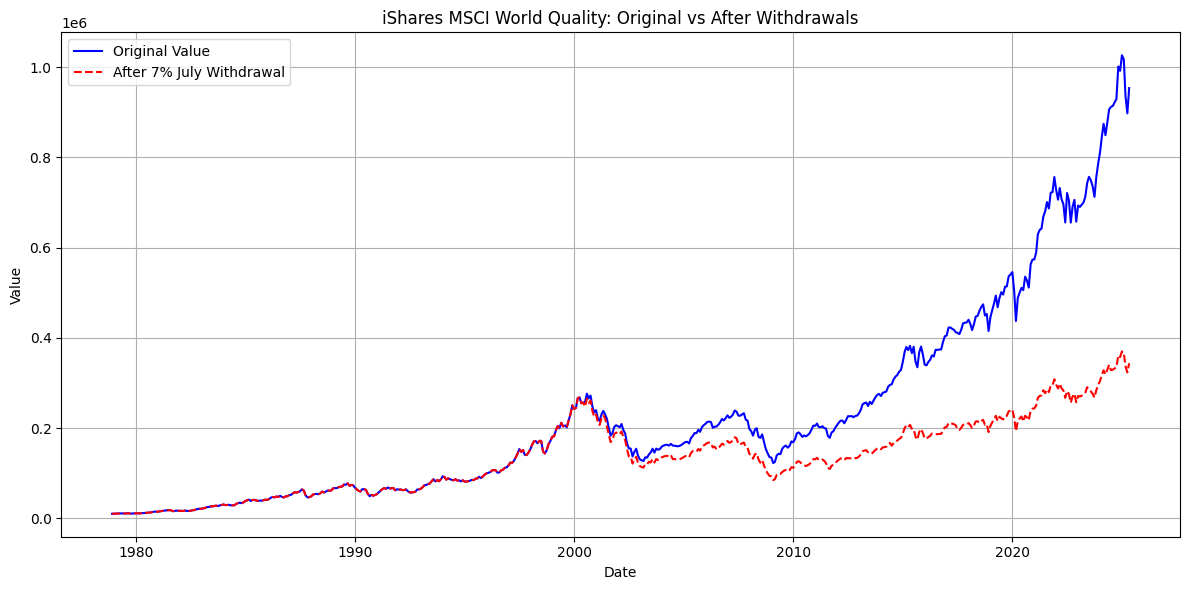

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV file
df = pd.read_csv('All World basic procentai.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m/%Y')

# Initialize adjusted value
df['Adjusted Value'] = df['MSCI World'].copy()

# Apply 4% withdrawal every July from 2000
for i in range(1, len(df)):
    current_date = df.loc[i, 'Date']
    prev_value = df.loc[i - 1, 'Adjusted Value']
    monthly_change = df.loc[i, 'Monthly Change (%)'] / 100

    # Withdraw 4% every July starting from 2000
    if current_date.year >= 2000 and current_date.month == 7:
        prev_value *= 0.96  # withdraw 4%
    
    # Apply monthly change
    df.loc[i, 'Adjusted Value'] = prev_value * (1 + monthly_change)

# Save the result
df.to_csv('Quality_after_withdrawals.csv', index=False)

# Plotting the original vs adjusted values
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['MSCI World'], label='Original Value', color='blue')
plt.plot(df['Date'], df['Adjusted Value'], label='After 4% July Withdrawal', color='red', linestyle='--')
plt.title('iShares MSCI World Quality: Original vs After Withdrawals')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


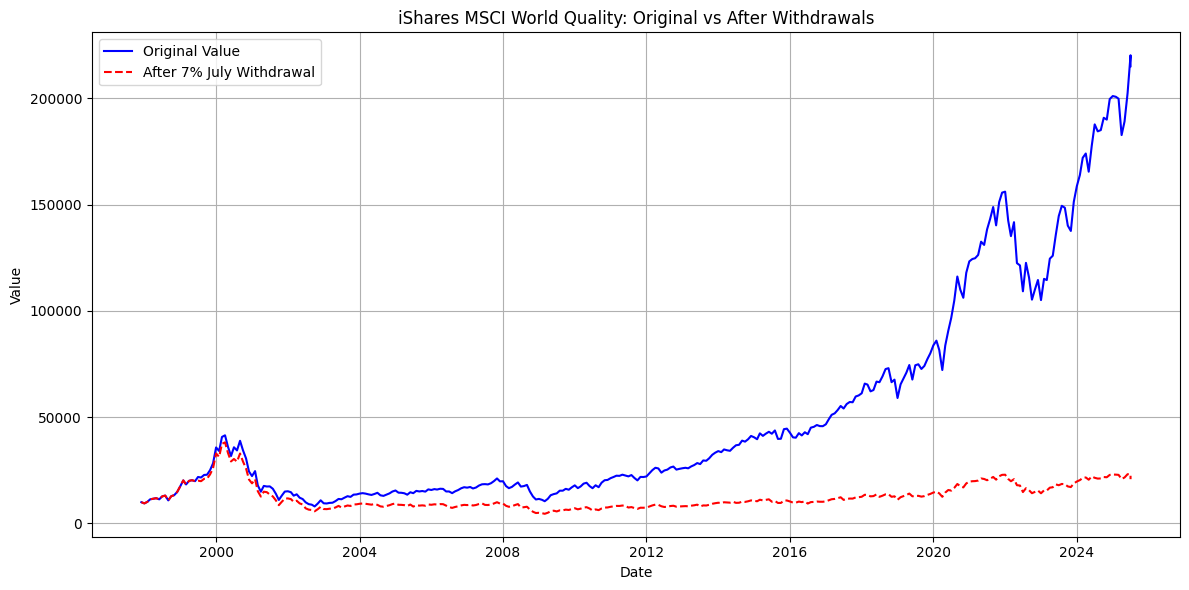

Final Original Value: 215081.06
Final Adjusted Value after 7% July withdrawals: 20828.66


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV file
df = pd.read_csv('ndx procentai 1998.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m/%Y')

df['Monthly Change (%)'] = (
    df['Monthly Change (%)']
    .astype(str)  # konvertuojam į string, jei yra NaN
    .str.replace('−', '-', regex=False)  # pakeičiam minus simbolį į normalų
    .str.replace(',', '', regex=False)  # jeigu yra kableliai kaip tūkstančio skirtukai
    .astype(float)  # konvertuojam į float
)


# Initialize adjusted value
df['Adjusted Value'] = df['Open'].copy()
df.loc[0, 'Adjusted Value'] = df.loc[0, 'Open']


# Apply 8% withdrawal every July from 2000
for i in range(1, len(df)):
    current_date = df.loc[i, 'Date']
    prev_value = df.loc[i - 1, 'Adjusted Value']
    monthly_change = df.loc[i, 'Monthly Change (%)'] / 100

    # Withdraw 7% every July starting from 2000
    if current_date.year >= 1999 and current_date.month == 7:
        prev_value *= 0.92  # withdraw 78%
    
    # Apply monthly change
    df.loc[i, 'Adjusted Value'] = prev_value * (1 + monthly_change)

# Save the result
df.to_csv('Quality_after_withdrawals.csv', index=False)

# Plotting the original vs adjusted values
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Open'], label='Original Value', color='blue')
plt.plot(df['Date'], df['Adjusted Value'], label='After 8% July Withdrawal', color='red', linestyle='--')
plt.title('iShares MSCI World Quality: Original vs After Withdrawals')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print final results
final_original = df['Open'].iloc[-1]
final_adjusted = df['Adjusted Value'].iloc[-1]

print(f"Final Original Value: {final_original:.2f}")
print(f"Final Adjusted Value after 7% July withdrawals: {final_adjusted:.2f}")


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^NDX']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Empty DataFrame
Columns: [(Adj Close, ^NDX), (Close, ^NDX), (High, ^NDX), (Low, ^NDX), (Open, ^NDX), (Volume, ^NDX)]
Index: []


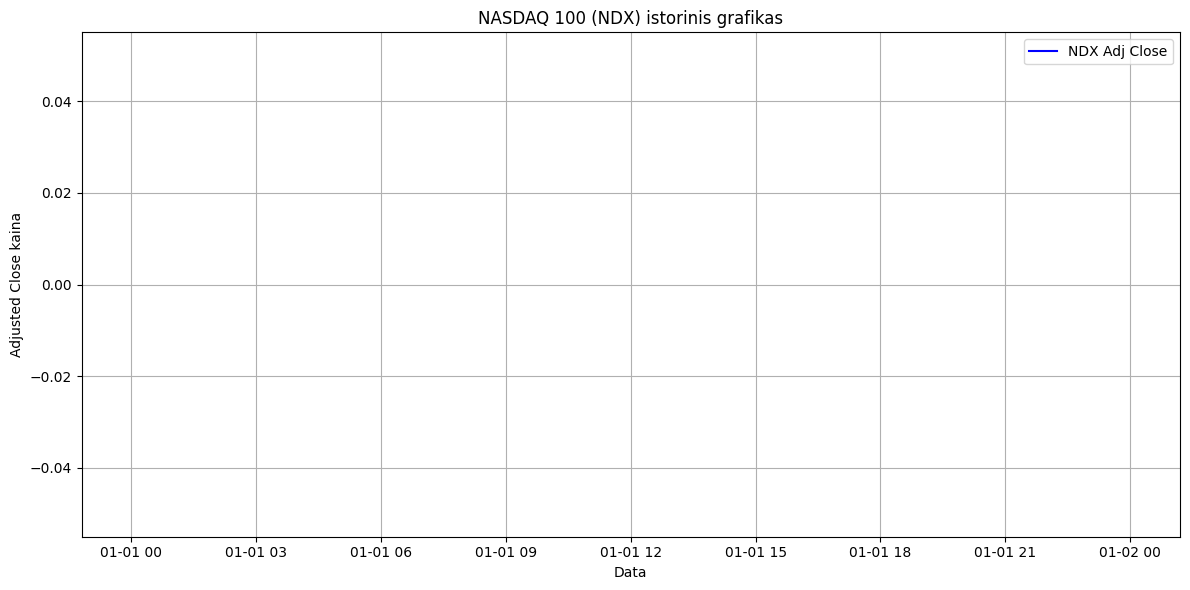

In [45]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Pasirenkame tickerį
ticker = "^NDX"  # Nasdaq 100 indexas

# Parsisiunčiame duomenis per yfinance
ndx = yf.download(ticker, start="1990-01-01", end=None)

# Parodome pirmas kelias eilutes
print(ndx.head())

# Išsaugome CSV jeigu reikia
ndx.to_csv("NDX_data.csv")

# Paprastas grafikas
plt.figure(figsize=(12, 6))
plt.plot(ndx.index, ndx["Adj Close"], label="NDX Adj Close", color='blue')
plt.title("NASDAQ 100 (NDX) istorinis grafikas")
plt.xlabel("Data")
plt.ylabel("Adjusted Close kaina")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [47]:
import yfinance as yf
import pandas as pd


ndx = yf.download("^NDX", start="1985-01-01", interval="1mo")
ndx = ndx.reset_index()


df = ndx[['Date', 'Open']]


df.to_csv("ndx_monthly_open.csv", index=False)
print("CSV failas sukurtas – ndx_monthly_open.csv")

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^NDX']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


CSV failas sukurtas – ndx_monthly_open.csv
